# EXPERIMENT 4: DATA WRANGLING AND DATA VISUALIZATION
> **Name:** *Joshane Eunice M. Faustino*
> 
> **Section:** *2ECE-C*
> 
> **Date:** *September 17, 2026*

In [7]:
import pandas as pd

In [8]:
import matplotlib.pyplot as plt

In [40]:
df = pd.read_excel("board2.xlsx")
df

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication
0,S1,Male,Instrumentation,Luzon,58,89,75,78
1,S2,Female,Communication,Mindanao,52,75,90,52
2,S3,Female,Instrumentation,Mindanao,83,74,77,57
3,S4,Male,Instrumentation,Visayas,65,58,91,68
4,S5,Male,Communication,Luzon,59,86,43,88
5,S6,Female,Microelectronics,Visayas,88,45,86,83
6,S7,Female,Instrumentation,Luzon,66,60,60,48
7,S8,Male,Instrumentation,Luzon,49,81,64,53
8,S9,Male,Instrumentation,Luzon,50,36,63,42
9,S10,Male,Microelectronics,Mindanao,80,84,61,44


In [41]:
data = df.copy()

In [42]:
data["Average"] = data[["Math", "GEAS", "Electronics", "Communication"]].mean(axis=1)

In [44]:
data

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication,Average
0,S1,Male,Instrumentation,Luzon,58,89,75,78,75.00
1,S2,Female,Communication,Mindanao,52,75,90,52,67.25
2,S3,Female,Instrumentation,Mindanao,83,74,77,57,72.75
3,S4,Male,Instrumentation,Visayas,65,58,91,68,70.50
4,S5,Male,Communication,Luzon,59,86,43,88,69.00
5,S6,Female,Microelectronics,Visayas,88,45,86,83,75.50
6,S7,Female,Instrumentation,Luzon,66,60,60,48,58.50
7,S8,Male,Instrumentation,Luzon,49,81,64,53,61.75
8,S9,Male,Instrumentation,Luzon,50,36,63,42,47.75
9,S10,Male,Microelectronics,Mindanao,80,84,61,44,67.25


In [16]:
df = df.rename(columns={"Communication": "Average"})
df

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Average,Average
0,S1,Male,Instrumentation,Luzon,58,89,75,78,75.00
1,S2,Female,Communication,Mindanao,52,75,90,52,67.25
2,S3,Female,Instrumentation,Mindanao,83,74,77,57,72.75
3,S4,Male,Instrumentation,Visayas,65,58,91,68,70.50
4,S5,Male,Communication,Luzon,59,86,43,88,69.00
5,S6,Female,Microelectronics,Visayas,88,45,86,83,75.50
6,S7,Female,Instrumentation,Luzon,66,60,60,48,58.50
7,S8,Male,Instrumentation,Luzon,49,81,64,53,61.75
8,S9,Male,Instrumentation,Luzon,50,36,63,42,47.75
9,S10,Male,Microelectronics,Mindanao,80,84,61,44,67.25


# A. VISAYAS COMMUNICATION DATAFRAME

In [46]:
VisComm = data[
    (data["Hometown"] == "Visayas") &
    (data["Track"] == "Communication")
][["Name", "Gender", "Math", "Electronics", "Average"]]
VisComm


,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


In [48]:
Number_Rows = len(VisComm)
Number_Rows

5

# B. VISAYAS FEMALE DATAFRAME

In [53]:
# Filter female students from Visayas
VisFemale = data[
    (data["Hometown"] == "Visayas") &
    (data["Gender"] == "Female")
][["Name", "Track", "GEAS", "Electronics", "Average"]]

VisFemale

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75


In [54]:
VisFemale.loc[VisFemale["Average"] >= 60]

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


# C. CATEGORY-AVERAGE VISUALIZATION

In [55]:
track_mean = data.groupby("Track", as_index=False)["Average"].mean()

print("Mean Average by Track:")
display(track_mean)

Mean Average by Track:


,Track,Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500


In [56]:
gender_mean = data.groupby("Gender", as_index=False)["Average"].mean()

print("Mean Average by Gender:")
display(gender_mean)

Mean Average by Gender:


,Gender,Average
0,Female,66.616667
1,Male,67.183333


In [57]:
hometown_mean = data.groupby("Hometown", as_index=False)["Average"].mean()

print("Mean Average by Hometown:")
display(hometown_mean)

Mean Average by Hometown:


,Hometown,Average
0,Luzon,68.083333
1,Mindanao,66.678571
2,Visayas,65.750000


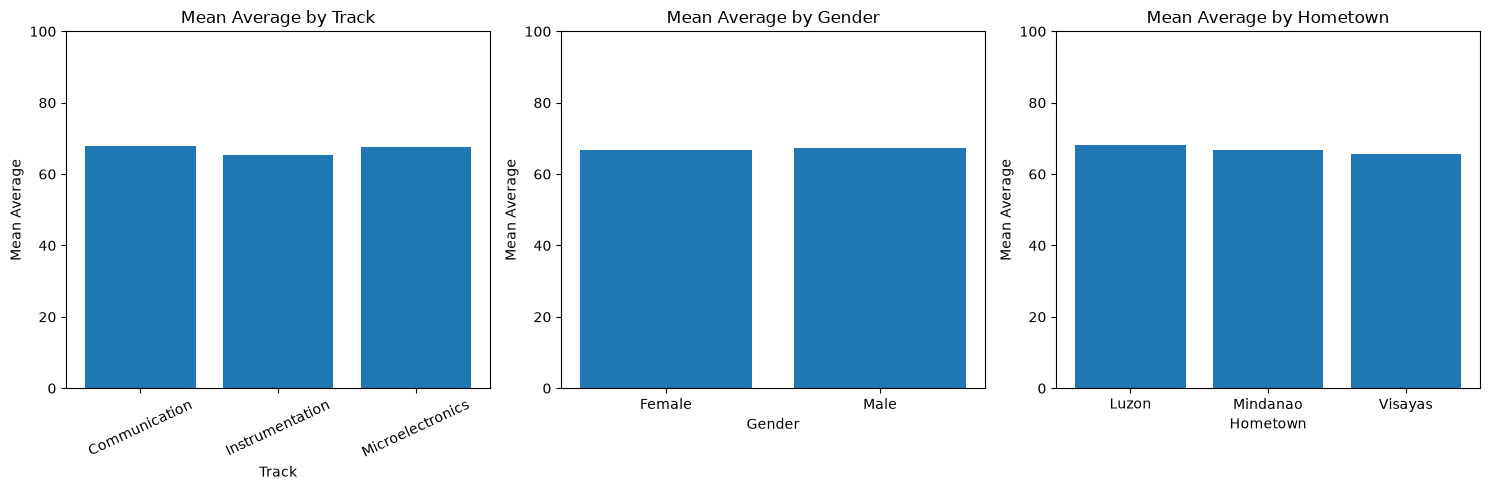

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Mean Average by Track
axes[0].bar(track_mean["Track"], track_mean["Average"])
axes[0].set_title("Mean Average by Track")
axes[0].set_xlabel("Track")
axes[0].set_ylabel("Mean Average")
axes[0].tick_params(axis="x", rotation=25)
axes[0].set_ylim(0, 100)

# Mean Average by Gender
axes[1].bar(gender_mean["Gender"], gender_mean["Average"])
axes[1].set_title("Mean Average by Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Mean Average")
axes[1].set_ylim(0, 100)

# Mean Average by Hometown
axes[2].bar(hometown_mean["Hometown"], hometown_mean["Average"])
axes[2].set_title("Mean Average by Hometown")
axes[2].set_xlabel("Hometown")
axes[2].set_ylabel("Mean Average")
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.show()

### Interpretation
1. Among the three tracks, **Microelectronics** students have the highest sample mean Average.
2. Between the two genders, **Female** students have the highest sample mean Average.
3. Among the three hometown regions, **Visayas** students have the highest sample mean Average.

These are descriptive observations about this particular sample only. A higher group mean does not,
by itself, establish that Track, Gender, or Hometown *causes* a higher board-exam score — other
factors could account for the difference, and the group sizes here are small.